# Optimal Coverage with Sensors using Heuristics

This notebook addresses a combinatorial optimization problem focused on sensor placement in a grid. The aim is to maximize the coverage of the grid while minimizing overlaps, redundant sensors, and sensors placed too closely to each other.

We implement a custom objective function `ObjFunSensor` and test it using:

- Shoot and Go
- Fast Simulated Annealing (FSA)
- Differential Evolution (DE)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import seaborn as sns
from typing import List, Callable, Dict, Any
from tqdm.notebook import tqdm
import pandas as pd

try:
    pwd = %pwd
    sys.path.append(os.path.join(pwd, 'src'))
    from src.objfun import ObjFun
    from src.heur_sg import ShootAndGo
    from src.heur_fsa import FastSimulatedAnnealing
    from src.heur_aux import Correction, CauchyMutation
    from src.heur_de import DifferentialEvolution
except (NameError, ImportError):
    print("Could not find 'src' directory")
    class ObjFun: pass
    class Heuristic: pass
    class Correction: pass
    class CauchyMutation: pass
    class ShootAndGo: pass
    class FastSimulatedAnnealing: pass
    class DifferentialEvolution: pass

## 1. Objective Function Definition

The `ObjFunSensor` class defines the sensor placement problem. The `evaluate` method calculates a **cost score** based on a solution vector `x`. The heuristics will attempt to **minimize** this cost.

- A high `total_covered` area reduces the cost (by minimizing its negative value).
- Penalties for `overlaps`, `n_sensors_used`, `ineffective_sensors`, and `too_close_penalty` increase the cost.

In [ ]:
class ObjFunSensor(ObjFun):
    def __init__(self, grid_size: int, sensor_range: int, alpha: float, beta: float, gamma: float, delta: float, epsilon: float, max_sensors: int):
        self.grid_size = grid_size
        self.sensor_range = sensor_range
        self.sensor_range_sq = sensor_range ** 2
        
        # Weights for the objective function components
        self.alpha, self.beta, self.gamma, self.delta, self.epsilon = alpha, beta, gamma, delta, epsilon

        self.max_sensors = max_sensors
        dim = 2 * self.max_sensors
        
        # Define the search space boundaries
        a, b = np.zeros(dim), np.full(dim, grid_size)
        super().__init__(fstar=-np.inf, a=a, b=b) 

        grid_x, grid_y = np.mgrid[0:self.grid_size, 0:self.grid_size]
        self.grid_coords = np.stack((grid_x, grid_y), axis=-1)

    def generate_point(self) -> np.ndarray:
        return np.random.uniform(low=self.a, high=self.b)

    def get_neighborhood(self, x: np.ndarray, radius: float = 1.0) -> List[np.ndarray]:
        neighbors = []
        dim = len(x)
        for i in range(dim):
            for delta in [-radius, radius]:
                x_new = np.copy(x)
                x_new[i] = np.clip(x[i] + delta, self.a[i], self.b[i])
                neighbors.append(x_new)
        return neighbors

    def _decode_solution(self, x: Any) -> np.ndarray:
        x_arr = np.asarray(x)
        positions = x_arr.reshape(-1, 2)
        int_positions = np.clip(np.round(positions), 0, self.grid_size - 1).astype(int)
        return np.unique(int_positions, axis=0)

    def evaluate(self, x: np.ndarray, detailed: bool = False) -> Any:
        sensor_coords = self._decode_solution(x)
        n_sensors_used = len(sensor_coords)

        if n_sensors_used == 0:
            metrics = {'score': 1e9, 'total_covered': 0, 'overlaps': 0, 'n_sensors_used': 0, 'ineffective_sensors': 0, 'too_close_penalty': 0}
            return metrics if detailed else metrics['score']

        dist_sq = np.sum((self.grid_coords[:, :, np.newaxis, :] - sensor_coords[np.newaxis, np.newaxis, :, :])**2, axis=3)
        coverage_by_sensor = (dist_sq <= self.sensor_range_sq).astype(np.int8)
        coverage_grid = np.sum(coverage_by_sensor, axis=2)

        total_covered = np.sum(coverage_grid > 0)
        overlaps = np.sum(coverage_grid[coverage_grid > 1] - 1)

        too_close_penalty = 0
        if n_sensors_used > 1:
            dists = np.linalg.norm(sensor_coords[:, np.newaxis, :] - sensor_coords[np.newaxis, :, :], axis=-1)
            too_close_penalty = np.sum(dists[np.triu_indices(n_sensors_used, k=1)] < 2)

        ineffective_sensors = 0
        if n_sensors_used > 0:
            for i in range(n_sensors_used):
                is_uniquely_covered_by_sensor_i = (coverage_grid == 1) & (coverage_by_sensor[:,:,i] == 1)
                if not np.any(is_uniquely_covered_by_sensor_i):
                    ineffective_sensors += 1
        
        score = (
            -self.alpha * total_covered 
            + self.beta * overlaps 
            + self.gamma * n_sensors_used
            + self.delta * ineffective_sensors 
            + self.epsilon * too_close_penalty
        )
        
        if not detailed:
            return score
        else:
            return {
                'score': score, 'total_covered': total_covered, 'overlaps': overlaps,
                'n_sensors_used': n_sensors_used, 'ineffective_sensors': ineffective_sensors,
                'too_close_penalty': too_close_penalty
            }

## 2. Visualization and Experiment Utilities

In [ ]:
def visualize_solution(best_x: np.ndarray, objfun: ObjFunSensor, title: str):
    sensor_coords = objfun._decode_solution(best_x)
    n_sensors = len(sensor_coords)
    
    coverage_grid = np.zeros((objfun.grid_size, objfun.grid_size))
    if n_sensors > 0:
        dist_sq = np.sum((objfun.grid_coords[:, :, np.newaxis, :] - sensor_coords[np.newaxis, np.newaxis, :, :])**2, axis=3)
        coverage_by_sensor = (dist_sq <= objfun.sensor_range_sq)
        coverage_grid = np.sum(coverage_by_sensor, axis=2)

    fig, ax = plt.subplots(figsize=(10, 8))
    
    im = ax.imshow(coverage_grid.T, cmap='viridis', origin='lower', vmin=0, vmax=max(1, np.max(coverage_grid)))
    
    if n_sensors > 0:
        ax.plot(sensor_coords[:, 0], sensor_coords[:, 1], 'X', color='red', markersize=10, mew=2, label=f'Sensors ({n_sensors})')

    ax.set_xticks(np.arange(0, objfun.grid_size, 5))
    ax.set_yticks(np.arange(0, objfun.grid_size, 5))
    ax.set_xticks(np.arange(0, objfun.grid_size, 1), minor=True)
    ax.set_yticks(np.arange(0, objfun.grid_size, 1), minor=True)
    ax.grid(which='major', color='w', linestyle='-', linewidth=1, alpha=0.5)
    ax.tick_params(which='major', bottom=True, left=True)
    ax.set_xlabel("X Coordinate", fontsize=12)
    ax.set_ylabel("Y Coordinate", fontsize=12)
    ax.set_title(title, fontsize=14)
    if n_sensors > 0:
        ax.legend()
    
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Coverage Level (Number of Sensors)', fontsize=12)
    
    plt.show()

In [ ]:
def run_experiments(
    grid_sizes: List[int],
    param_grid: List[Dict[str, Any]],
    heuristic_builder: Callable[[ObjFunSensor, Dict[str, Any]], Any],
    n_runs: int = 100,  
    verbose: bool = True
) -> pd.DataFrame:
    results = []

    objfun_params = {
        'sensor_range': 3,
        'alpha': 1.0,     # Reward for coverage
        'beta': 0.2,      # Penalty for overlap
        'gamma': 1.5,     # Penalty for number of sensors
        'delta': 2.0,     # Penalty for useless sensors
        'epsilon': 2.0    # Penalty for sensors being too close
    }

    for grid_size in grid_sizes:
        max_sensors = int((grid_size * grid_size) / (np.pi * objfun_params['sensor_range']**2) * 1.5)
        
        for params in param_grid:
            param_str = ", ".join(f"{k}={v}" for k, v in params.items())
            desc = f"Grid {grid_size}, Params: {param_str}"
            
            pbar = tqdm(range(n_runs), desc=desc, disable=not verbose)
            for run in pbar:
                objfun = ObjFunSensor(
                    grid_size=grid_size,
                    max_sensors=max_sensors,
                    **objfun_params
                )
                
                heur = heuristic_builder(objfun, params)
                
                search_result = heur.search()

                final_metrics = objfun.evaluate(search_result['best_x'], detailed=True)

                pbar.set_postfix(score=f"{-final_metrics['score']:.2f}")

                results.append({
                    'grid_size': grid_size,
                    **params,
                    'run': run,
                    'best_x': search_result['best_x'], 
                    **final_metrics
                })
               
    return pd.DataFrame(results)

## 3. Heuristic Configuration
Define the parameter grids and builder functions for each heuristic.

In [5]:
MAX_EVAL = 10000

def shoot_and_go_builder(objfun: ObjFunSensor, params: Dict[str, Any]):
    return ShootAndGo(of=objfun, maxeval=MAX_EVAL, hmax=params['hmax'])

def fsa_builder(objfun: ObjFunSensor, params: Dict[str, Any]):
    mutation = CauchyMutation(r=0.5, correction=Correction(objfun))
    return FastSimulatedAnnealing(of=objfun, maxeval=MAX_EVAL, T0=params['t0'], n0=1, alpha=params['alpha'], mutation=mutation)

def de_builder(objfun: ObjFunSensor, params: Dict[str, Any]):
    return DifferentialEvolution(of=objfun, maxeval=MAX_EVAL, N=params['N'], F=params['F'], CR=params['CR'])

sng_params = [
    {'hmax': 0},      
    {'hmax': 10},     
    {'hmax': 50}     
]

fsa_params = [
    {'t0': 100, 'alpha': 0.95},
    {'t0': 500, 'alpha': 0.95},
    {'t0': 500, 'alpha': 0.99}
]

de_params = [
    {'N': 20, 'F': 0.5, 'CR': 0.9},
    {'N': 40, 'F': 0.5, 'CR': 0.9},
    {'N': 40, 'F': 0.8, 'CR': 0.5}
]

## 4. Running the Experiments


In [7]:
test_grid_sizes = [10, 25, 40]
num_runs = 100 

print("--- Running Shoot and Go Experiments ---")
sng_results = run_experiments(test_grid_sizes, sng_params, shoot_and_go_builder, n_runs=num_runs)
sng_results['heuristic'] = 'SNG'

print("\n--- Running Fast Simulated Annealing Experiments ---")
fsa_results = run_experiments(test_grid_sizes, fsa_params, fsa_builder, n_runs=num_runs)
fsa_results['heuristic'] = 'FSA'

print("\n--- Running Differential Evolution Experiments ---")
de_results = run_experiments(test_grid_sizes, de_params, de_builder, n_runs=num_runs)
de_results['heuristic'] = 'DE'

all_results = pd.concat([sng_results, fsa_results, de_results], ignore_index=True)

print("\n\n--- Experiment run complete. ---")
all_results.head()

--- Running Shoot and Go Experiments ---


Grid 10, Params: hmax=0:   0%|          | 0/100 [00:00<?, ?it/s]

Grid 10, Params: hmax=10:   0%|          | 0/100 [00:00<?, ?it/s]

Grid 10, Params: hmax=50:   0%|          | 0/100 [00:00<?, ?it/s]

Grid 25, Params: hmax=0:   0%|          | 0/100 [00:00<?, ?it/s]

...

Grid 40, Params: N=20, F=0.5, CR=0.9:   0%|          | 0/100 [00:00<?, ?it/s]

Grid 40, Params: N=40, F=0.5, CR=0.9:   0%|          | 0/100 [00:00<?, ?it/s]

Grid 40, Params: N=40, F=0.8, CR=0.5:   0%|          | 0/100 [00:00<?, ?it/s]



--- Experiment run complete. ---


,grid_size,hmax,run,best_x,score,total_covered,overlaps,n_sensors_used,ineffective_sensors,too_close_penalty,heuristic,t0,alpha,N,F,CR
0,10,0.0,0,"[7.563339132915377, 2.4012452297098106, 6.8425...",-84.5,97,25,5,0,0,SNG,NaN,NaN,NaN,NaN,NaN
1,10,0.0,1,"[2.495423773416624, 1.1044907220086553, 3.7188...",-81.9,94,23,5,0,0,SNG,NaN,NaN,NaN,NaN,NaN
2,10,0.0,2,"[7.765842931850321, 2.3224213152070847, 0.4211...",-83.1,94,17,5,0,0,SNG,NaN,NaN,NaN,NaN,NaN
3,10,0.0,3,"[9.195907582206168, 4.5348609926396755, 6.5772...",-84.1,96,22,5,0,0,SNG,NaN,NaN,NaN,NaN,NaN
4,10,0.0,4,"[6.699079151303357, 1.9705336965446107, 3.5687...",-85.1,96,17,5,0,0,SNG,NaN,NaN,NaN,NaN,NaN


## 5. Analysis and Visualization of Results

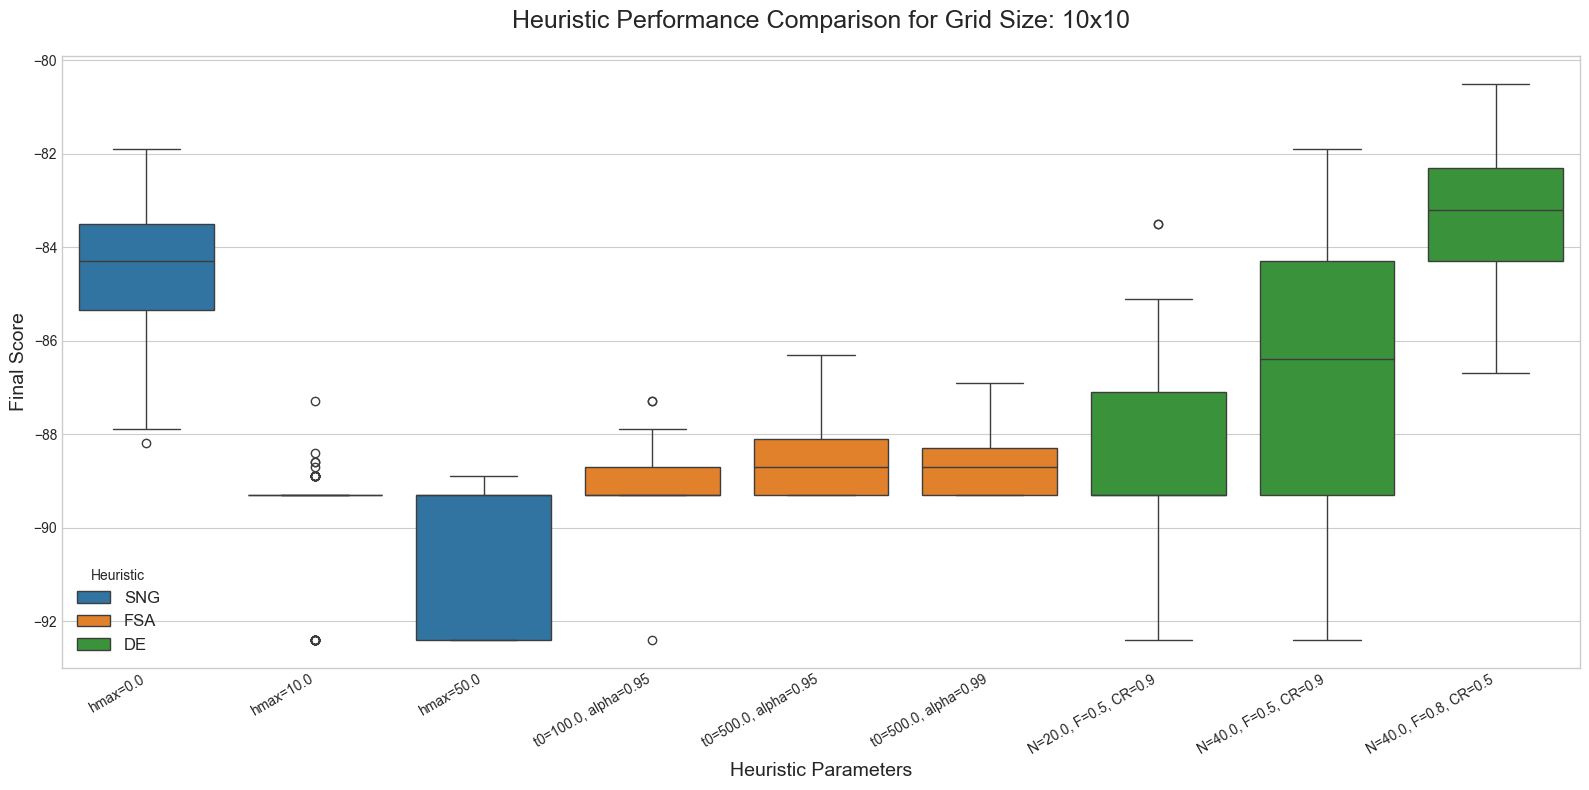

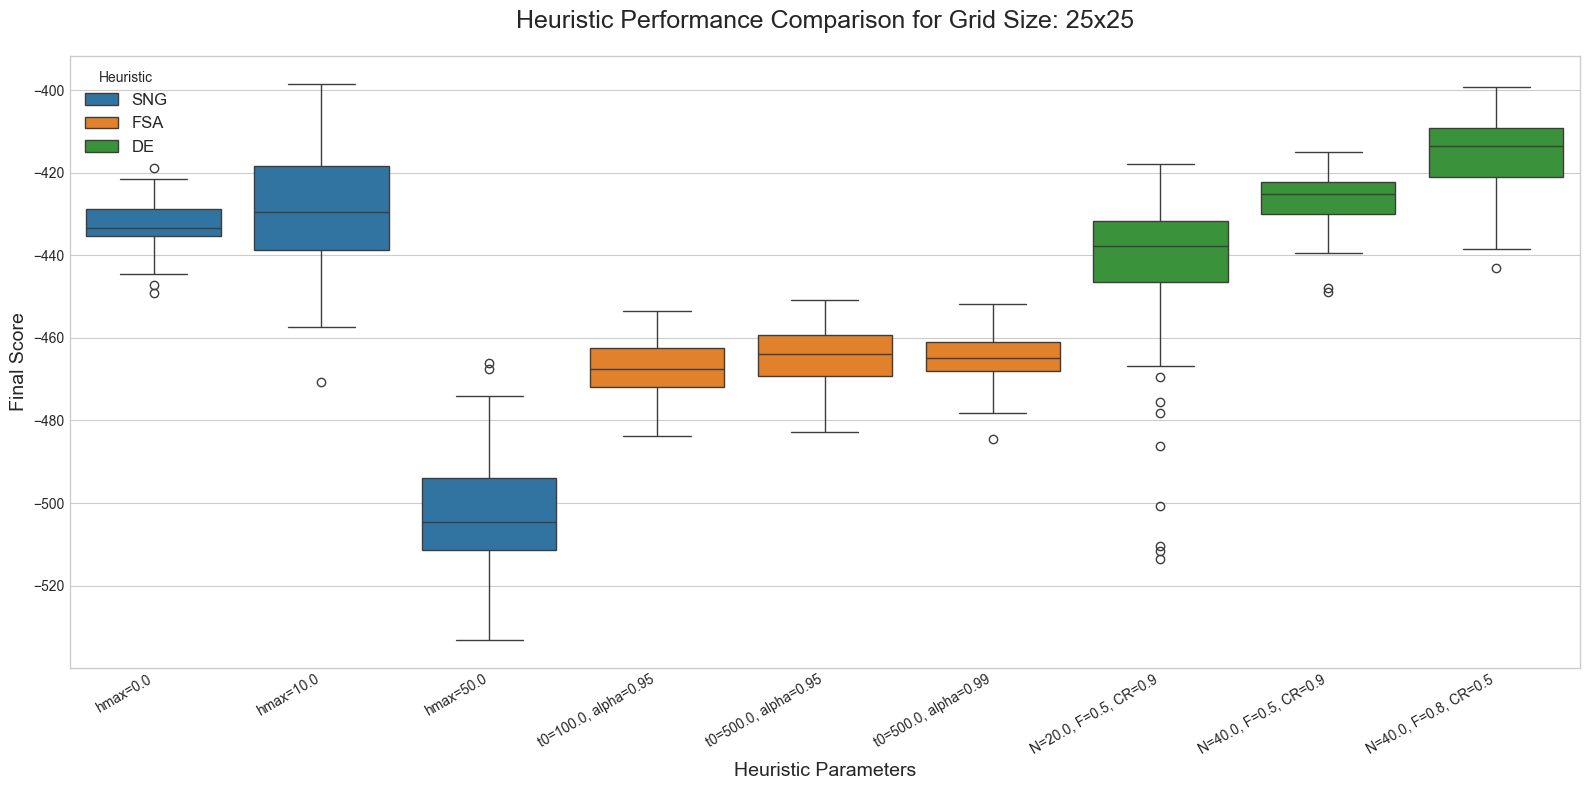

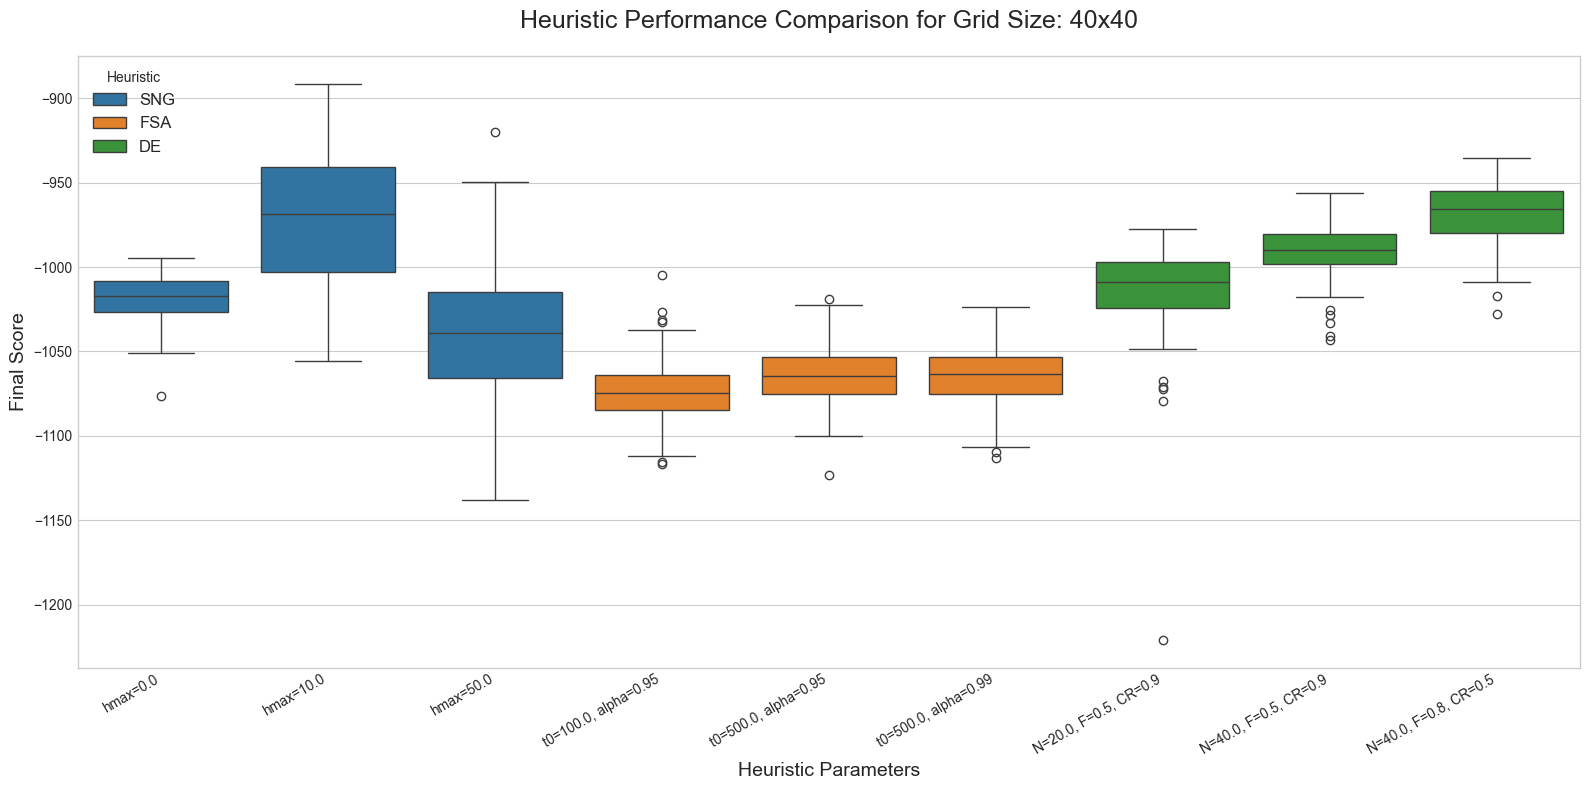

In [16]:
all_results['params'] = ''
sng_mask = all_results['heuristic'] == 'SNG'
all_results.loc[sng_mask, 'params'] = 'hmax=' + all_results.loc[sng_mask, 'hmax'].astype(str)

fsa_mask = all_results['heuristic'] == 'FSA'
all_results.loc[fsa_mask, 'params'] = 't0=' + all_results.loc[fsa_mask, 't0'].astype(str) + ', alpha=' + all_results.loc[fsa_mask, 'alpha'].astype(str)

de_mask = all_results['heuristic'] == 'DE'
all_results.loc[de_mask, 'params'] = 'N=' + all_results.loc[de_mask, 'N'].astype(str) + ', F=' + all_results.loc[de_mask, 'F'].astype(str) + ', CR=' + all_results.loc[de_mask, 'CR'].astype(str)

plt.style.use('seaborn-v0_8-whitegrid')
for grid_size in all_results['grid_size'].unique():
    
    fig, ax = plt.subplots(figsize=(16, 8))
    
    # Filter data for the current grid size
    data_subset = all_results[all_results['grid_size'] == grid_size]
    
    sns.boxplot(data=data_subset, x='params', y='score', hue='heuristic', ax=ax)
    
    ax.set_title(f'Heuristic Performance Comparison for Grid Size: {grid_size}x{grid_size}', fontsize=18, pad=20)
    ax.set_xlabel('Heuristic Parameters', fontsize=14)
    ax.set_ylabel('Final Score', fontsize=14)
    ax.tick_params(axis='x', labelrotation=30)
    
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')
        
    ax.legend(title='Heuristic', fontsize=12)
    plt.tight_layout()
    plt.show()

--- Best Overall Result Found ---
Grid Size: 40x40
Heuristic: DE with parameters: N=20.0, F=0.5, CR=0.9
Score: -1220.80
-----------------------------------
Detailed Metrics of the Best Solution:
  Grid Cells Covered: 1478 / 1600
  Sensors Used:       84
  Overlaps:           646
  Ineffective Sensors:  0
  Proximity Penalty:    1

--- Visualizing the Best Found Solution ---


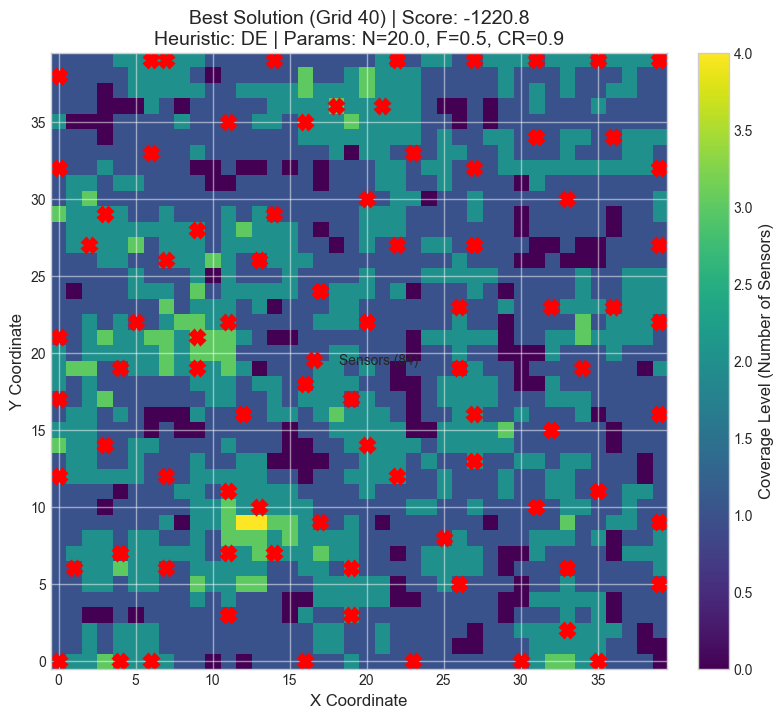

In [15]:
best_run = all_results.loc[all_results['score'].idxmin()]

print("--- Best Overall Result Found ---")
print(f"Grid Size: {best_run['grid_size']}x{best_run['grid_size']}")
print(f"Heuristic: {best_run.get('heuristic', 'N/A')} with parameters: {best_run.get('params', 'N/A')}")
print(f"Score: {best_run['score']:.2f}")
print("-" * 35)
print("Detailed Metrics of the Best Solution:")
print(f"  Grid Cells Covered: {best_run['total_covered']:.0f} / {int(best_run['grid_size']**2)}")
print(f"  Sensors Used:       {best_run['n_sensors_used']:.0f}")
print(f"  Overlaps:           {best_run['overlaps']:.0f}")
print(f"  Ineffective Sensors:  {best_run['ineffective_sensors']:.0f}")
print(f"  Proximity Penalty:    {best_run['too_close_penalty']:.0f}")


print("\n--- Visualizing the Best Found Solution ---")

vis_objfun = ObjFunSensor(
    grid_size=int(best_run['grid_size']),
    sensor_range=3,  
    alpha=1.0,       
    beta=0.2,        
    gamma=1.5,      
    delta=2.0,       
    epsilon=2.0,     
    max_sensors=int((int(best_run['grid_size']) * int(best_run['grid_size'])) / (np.pi * 3**2) * 1.5)  
)

best_x_solution = best_run['best_x']

title = (
    f"Best Solution (Grid {int(best_run['grid_size'])}) | Score: {best_run['score']:.1f}\n"
    f"Heuristic: {best_run['heuristic']} | Params: {best_run['params']}"
)
visualize_solution(best_x_solution, vis_objfun, title=title)

# Analysis and Evaluation of Heuristics

## 1. Objective and Methodology of the Experiment

The objective of the experiment was a quantitative comparison of the performance of three stochastic heuristics – Shoot and Go (SNG), Fast Simulated Annealing (FSA), and Differential Evolution (DE) – for a sensor placement optimization problem. 

Solution quality was evaluated by minimizing a cost function that integrates negatively weighted coverage and positively weighted penalties for sensor count, overlaps, inefficiency, and proximity. The experiment was conducted on three grid sizes (10x10, 25x25, 40x40), with each heuristic configuration tested in 100 independent runs to ensure statistical robustness of the results.

## 2. Performance Analysis Based on Aggregated Data

An analysis of boxplot graphs, visualizing the distribution of results from the 100 runs, reveals trends in the typical behavior of each heuristic:

- **Shoot and Go (SNG):**  
  This heuristic, especially in the extended local search variant (hmax=50), consistently achieves the lowest median cost values. The overall result distribution (given by the interquartile range and whiskers) is systematically shifted towards lower (better) values compared to the others. This indicates that SNG is the most reliable method for finding low-cost solutions.

- **Fast Simulated Annealing (FSA):**  
  FSA shows stable performance with low variance, as evident from the short height of the boxplots. However, its solutions are consistently more expensive (worse) than those found by SNG with hmax>0, but cheaper (better) than the typical results of the DE method.

- **Differential Evolution (DE):**  
  Based on the aggregated data, DE appears to be the least effective heuristic. Its results exhibit the highest median cost values and wide variability, indicating unreliability and a tendency to converge to high-cost solutions.

## 3. Analysis of the Best Found Solution and Discussion of the Discrepancy

The single best solution across all experimental runs was found using the DE heuristic (N=20, F=0.5, CR=0.9) on the 40x40 grid, achieving a final cost of -1220.80.

This fact directly contradicts the aggregated data, where this DE configuration appears among the least effective. This phenomenon can be explained as follows:

The result of -1220.80 represents an **extreme outlier**. While 99 out of 100 runs of the DE configuration converged to suboptimal solutions (as shown by the boxplot), one run followed an exceptionally successful trajectory. As a population-based method, Differential Evolution may have randomly generated a unique initial population or encountered a series of advantageous mutations in that single run, leading it to converge to a very deep local minimum that other methods, including the more reliable SNG, failed to discover.

## 4. Conclusion

The analysis revealed complex behavior that prevents declaring any heuristic as absolutely superior without additional context.

- **For reliably finding high-quality solutions:**  
  In scenarios where robustness and consistent achievement of good results in a limited number of runs is key, **Shoot and Go with hmax=50** emerges as the most suitable method. It offers the best trade-off between typical performance and reliability.
